<div style="display:flex;align-items:center;gap:18px;border-bottom:1px solid #d9d4ca;padding-bottom:18px">
  <img src="assets/belieflens-logo.png" width="86" alt="BeliefLens logo">
  <div><h1 style="margin:0">Verity public API</h1><p style="margin:5px 0 0;color:#0b7774;font-weight:700">Powered by the BeliefLens analytics engine</p></div>
</div>

This notebook shows how to call the fixed, keyless Verity service and turn its JSON response into an inspectable governance report. Verity generates an evidence-bounded answer; the BeliefLens analytics engine measures phrase support, sensitivity to equivalent prompt wording, dependence on supplied evidence, and claim-to-source attribution.

**Important:** these are uncalibrated, execution-specific diagnostics—not a factual-truth certificate or a reference posterior. For the mathematical construction, read [*Stochastic Semantic Evidence Graphs: Uncertainty Propagation and Governance for Agentic AI*](https://belieflens.org/assets/belieflens-stochastic-evidence-graphs-preprint.pdf).

## What you will do

1. Inspect the public quota before making a request.
2. Submit either supplied evidence or a web-grounded question.
3. Convert the nested response into claim- and source-level tables.
4. Visualize the annotated answer, uncertainty channels, and stochastic semantic evidence graph.
5. Use the same call as a LangChain or LangGraph node.
6. locate the corresponding OpenTelemetry trace in the protected Jaeger interface.

The included response fixture is a real, sanitized API result. `RUN_LIVE` is off by default, so reading the notebook consumes no public quota.

In [1]:
from pathlib import Path
import html
import json

import httpx
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

BASE_URL = "https://demo.belieflens.org"
RUN_LIVE = False  # Change deliberately to True to spend one public request.

def locate(name):
    candidates = [Path(name), Path.cwd() / name, Path.cwd() / "engine/examples/notebooks/verity" / name]
    return next((path for path in candidates if path.exists()), None)


## 1. Inspect the service budget

The public interface has two independent protections: a rolling per-IP throttle and a persistent, aggregate UTC daily spend ledger. A distributed burst therefore cannot bypass the global daily cap. HTTP `429` means stop; the notebook does not retry automatically.

In [2]:
try:
    with httpx.Client(base_url=BASE_URL, timeout=30) as client:
        budget_response = client.get("/v1/seg/public-budget")
        budget_response.raise_for_status()
        budget = budget_response.json()
except httpx.HTTPError:
    fixture = locate("sample_verity_result.json")
    budget = json.loads(fixture.read_text()).get("public_budget", {}) if fixture else {}
    budget["note"] = "Live budget unavailable; showing the bundled run's ledger."
pd.Series(budget, name="Public Verity budget")


day_utc                              2026-09-04
limit_usd                                   3.0
debited_usd                                0.05
remaining_usd                              2.95
request_count                                 1
accounting       conservative pre-request debit
Name: Public Verity budget, dtype: object

## 2. Define one auditable request

This example supplies a short passage, so its evidence boundary is explicit. Set `auto_retrieve=True` with an empty evidence list to let Verity retrieve public passages. Supplying evidence is preferable when reproducing an analysis because the source text remains fixed.

In [3]:
request_payload = {
    "prompt": "Based only on the supplied evidence, what changed in the policy rate?",
    "auto_retrieve": False,
    "evidence": [{
        "source_id": "illustrative-policy-release",
        "title": "Illustrative policy release",
        "uri": "https://example.org/illustrative-policy-release",
        "passage": "At its meeting, the committee raised the target range from 5.00–5.25% to 5.25–5.50%.",
    }],
}
display(pd.DataFrame(request_payload["evidence"]))


,source_id,title,uri,passage
0,illustrative-policy-release,Illustrative policy release,https://example.org/illustrative-policy-release,"At its meeting, the committee raised the targe..."


### Make the call—or load the bundled response

The endpoint is `POST /v1/seg/chat`. It requires no key on the public host. The response headers and body carry a trace ID.

In [4]:
if RUN_LIVE:
    if float(budget.get("remaining_usd", 0)) < 0.05:
        raise RuntimeError("The public daily budget is exhausted; use the bundled result.")
    with httpx.Client(base_url=BASE_URL, timeout=180) as client:
        response = client.post("/v1/seg/chat", json=request_payload)
        if response.status_code == 429:
            raise RuntimeError(f"Public throttle or budget reached: {response.text}")
        response.raise_for_status()
        result = response.json()
        trace_url = response.headers.get("X-BeliefLens-Trace-Url")
else:
    fixture = locate("sample_verity_result.json")
    if fixture is None:
        raise FileNotFoundError("Run from the repository root or this notebook directory.")
    result = json.loads(fixture.read_text())
    trace_url = result.get("trace_url")

display(Markdown(f"**Answer:** {result['response']}"))
pd.Series({
    "certificate": result["certificate"]["overall_status"],
    "claims analyzed": len(result["spans"]),
    "sources ranked": len(result.get("provenance_ranking", [])),
    "trace ID": result.get("trace_id"),
}, name="Run summary")


**Answer:** The committee raised the target range for the policy rate from 5.00–5.25% to 5.25–5.50%. This indicates an increase in the policy rate.

certificate                                    warn
claims analyzed                                   2
sources ranked                                    1
trace ID           f6aee053ce8602bf813a4d686e4b0d7c
Name: Run summary, dtype: object

## 3. Turn nested JSON into analysis tables

Each span is a claim-like phrase. Prompt instability measures change under a meaning-preserving prompt perturbation. Evidence sensitivity measures change when a source is removed; a high value can be appropriate when the claim genuinely depends on that source. Attribution bounds retain dependence uncertainty using Fréchet bounds rather than silently assuming independent sources.

In [5]:
claim_rows = []
for span in result["spans"]:
    phrase = span.get("phrase_probability") or {}
    prompt = span.get("prompt_instability") or {}
    evidence = span.get("evidence_sensitivity") or {}
    attribution = span.get("attribution_uncertainty") or {}
    claim_rows.append({
        "claim": span["text"],
        "status": span["status"],
        "phrase_support": phrase.get("geometric_mean_token_probability"),
        "prompt_instability": prompt.get("maximum_semantic_instability"),
        "evidence_sensitivity": evidence.get("mean_semantic_influence"),
        "attribution_lower": (attribution.get("attributable_probability_bounds") or [None])[0],
        "residual_upper": (attribution.get("residual_unattributed_probability_bounds") or [None, None])[-1],
    })
claims = pd.DataFrame(claim_rows)
claims


,claim,status,phrase_support,prompt_instability,evidence_sensitivity,attribution_lower,residual_upper
0,The committee raised the target range for the ...,green,0.938846,0.09,1.0,0.999994,0.000006
1,This indicates an increase in the policy rate,orange,0.811693,0.18,1.0,0.999975,0.000025


## 4. Visualize the answer and its uncertainty channels

Green, amber, and red summarize the worst applicable gate for each measured phrase. Read the component columns before acting: evidence sensitivity is dependence, not an error by itself.

In [6]:
palette = {"green": "#dff1e7", "orange": "#fff0d2", "red": "#fde1df"}
ink = {"green": "#17643d", "orange": "#945b00", "red": "#9b302c"}
answer = result["response"]
parts, cursor = [], 0
for span in sorted(result["spans"], key=lambda item: item["start"]):
    parts.append(html.escape(answer[cursor:span["start"]]))
    text = html.escape(answer[span["start"]:span["end"]])
    color = span["status"]
    parts.append(f"<mark style='background:{palette[color]};color:{ink[color]};padding:2px 4px;border-radius:4px' title='{color}'>{text}</mark>")
    cursor = span["end"]
parts.append(html.escape(answer[cursor:]))
display(HTML("<div style='font:20px/1.8 Georgia,serif;padding:20px;border:1px solid #ddd;border-radius:12px'>" + ''.join(parts) + "</div>"))


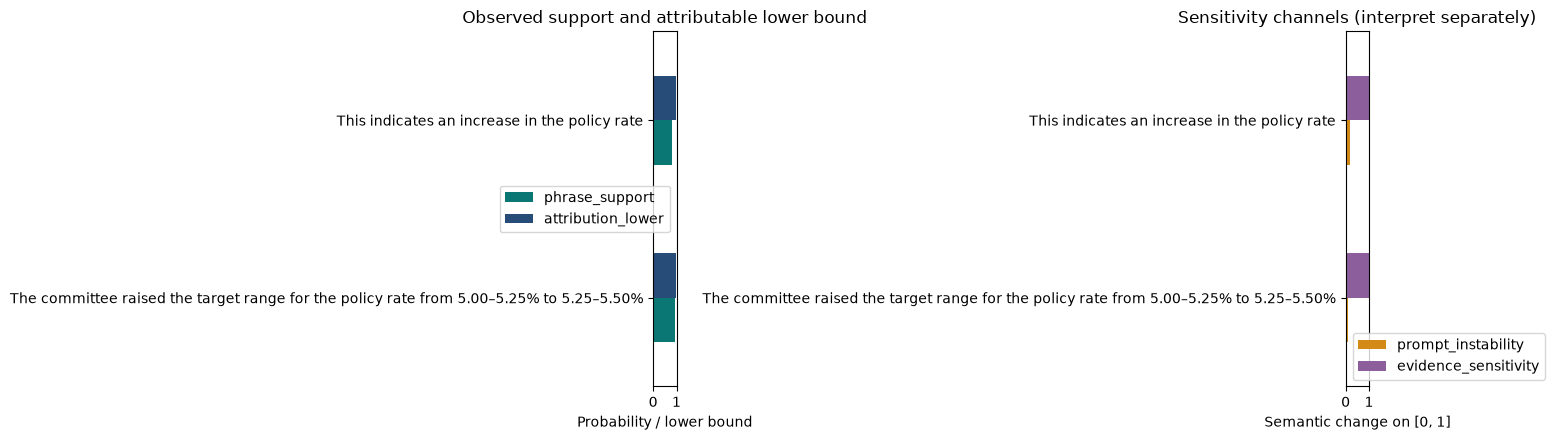

In [7]:
plot_data = claims.set_index("claim")[["phrase_support", "attribution_lower", "prompt_instability", "evidence_sensitivity"]]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_data[["phrase_support", "attribution_lower"]].plot.barh(ax=axes[0], color=["#0b7774", "#274c77"])
axes[0].set_title("Observed support and attributable lower bound")
axes[0].set_xlim(0, 1); axes[0].set_xlabel("Probability / lower bound"); axes[0].set_ylabel("")
plot_data[["prompt_instability", "evidence_sensitivity"]].plot.barh(ax=axes[1], color=["#d48a17", "#8c5e9b"])
axes[1].set_title("Sensitivity channels (interpret separately)")
axes[1].set_xlim(0, 1); axes[1].set_xlabel("Semantic change on [0, 1]"); axes[1].set_ylabel("")
for ax in axes: ax.grid(axis="x", alpha=.2)
plt.tight_layout()


## 5. Visualize the stochastic semantic evidence graph

The graph preserves sources and claims as separate nodes. An evidence-to-claim edge stores the measured relation law; claim nodes then compose into the answer. This makes it possible to locate a governance concern without collapsing every uncertainty source into one score.

,node_id,node_type,value,source_id,uri,authority_class
0,query,query,"Based only on the supplied evidence, what chan...",,,
1,answer,answer,The committee raised the target range for the ...,,,
2,passage:illustrative-policy-release,evidence_passage,,illustrative-policy-release,https://example.org/illustrative-policy-release,unclassified
3,claim:1,answer_claim,The committee raised the target range for the ...,,,
4,claim:2,answer_claim,This indicates an increase in the policy rate,,,


,source,target,edge_type,measurement_status
0,query,answer,conditions_generation,
1,passage:illustrative-policy-release,claim:1,claim_evidence_relation,measured_uncalibrated
2,passage:illustrative-policy-release,claim:2,claim_evidence_relation,measured_uncalibrated
3,claim:1,answer,composes,
4,claim:2,answer,composes,


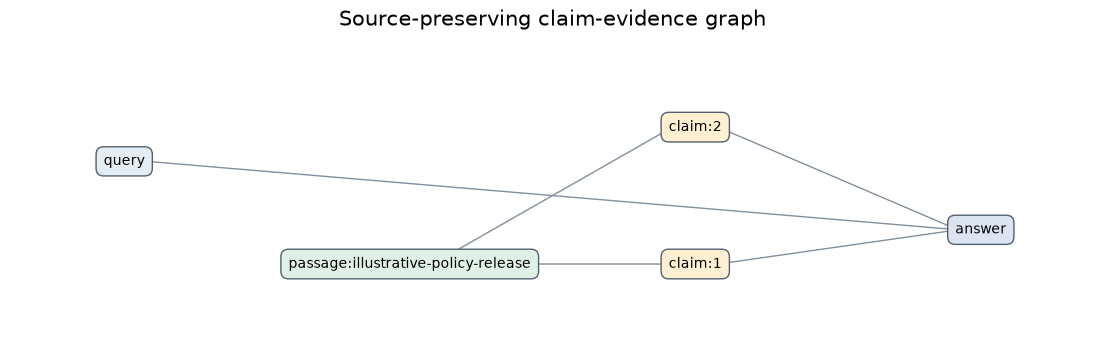

In [8]:
graph = result["semantic_evidence_graph"]
nodes = pd.DataFrame(graph["nodes"])
edges = pd.DataFrame(graph["edges"])
display(nodes.fillna(""))
display(edges[[column for column in ["source", "target", "edge_type", "measurement_status"] if column in edges]].fillna(""))

# A dependency-free graph drawing with fixed layers: evidence → claims → answer.
source_ids = nodes.loc[nodes.node_type == "evidence_passage", "node_id"].tolist()
claim_ids = nodes.loc[nodes.node_type == "answer_claim", "node_id"].tolist()
positions = {"query": (0, 1), "answer": (3, .5)}
positions.update({node: (1, i + .25) for i, node in enumerate(source_ids)})
positions.update({node: (2, i + .25) for i, node in enumerate(claim_ids)})
fig, ax = plt.subplots(figsize=(14, max(4, 1.6 * max(len(source_ids), len(claim_ids)))))
for _, edge in edges.iterrows():
    if edge.source in positions and edge.target in positions:
        x1, y1 = positions[edge.source]; x2, y2 = positions[edge.target]
        ax.annotate("", xy=(x2-.08, y2), xytext=(x1+.08, y1), arrowprops={"arrowstyle": "->", "color": "#82909d"})
for node_id, (x, y) in positions.items():
    node_type = nodes.loc[nodes.node_id == node_id, "node_type"].iloc[0]
    color = {"query": "#e5edf4", "evidence_passage": "#dff1e7", "answer_claim": "#fff0d2", "answer": "#dce4f2"}.get(node_type, "#eee")
    ax.text(x, y, node_id, ha="center", va="center", bbox={"boxstyle": "round,pad=.55", "facecolor": color, "edgecolor": "#52606d"})
ax.set_xlim(-.4, 3.4); ax.set_ylim(-.4, max([p[1] for p in positions.values()]) + .6); ax.axis("off")
ax.set_title("Source-preserving claim-evidence graph", fontsize=15, pad=14)
plt.show()


## 6. Use Verity in LangChain or LangGraph

Install `langchain-core` if it is not already available. The small adapter below is self-contained so this public notebook does not depend on private server source. It returns the complete result rather than reducing it to a single score, allowing downstream policy code to inspect the relevant gates. The packaged BeliefLens SDK exposes the equivalent `belieflens.integrations.langchain.VerityRunnable`.

In [ ]:
try:
    from langchain_core.runnables import Runnable
except ImportError:
    Runnable = object  # The direct HTTP example still works without LangChain.

class VerityRunnable(Runnable):
    def __init__(self, base_url=BASE_URL, auto_retrieve=True):
        self.base_url, self.auto_retrieve = base_url, auto_retrieve

    def invoke(self, value, config=None, **kwargs):
        prompt = value["prompt"] if isinstance(value, dict) else str(value)
        evidence = value.get("evidence", []) if isinstance(value, dict) else []
        payload = {"prompt": prompt, "evidence": evidence, "auto_retrieve": self.auto_retrieve and not evidence}
        with httpx.Client(base_url=self.base_url, timeout=180) as client:
            response = client.post("/v1/seg/chat", json=payload)
            response.raise_for_status()
            return response.json()

verity_node = VerityRunnable()
# One deliberate live call:
# chain_result = verity_node.invoke({"prompt": "What factors make credit markets fragile?"})


## 7. Trace the request with OpenTelemetry and Jaeger

BeliefLens propagates W3C trace context and exports service spans over OTLP. The API returns `X-BeliefLens-Trace-Id` and, when configured, `X-BeliefLens-Trace-Url`. The Jaeger browser at [traces.belieflens.org](https://traces.belieflens.org/) is restricted to authorized operators because it contains cross-user operational metadata. Public callers can provide the trace ID when reporting a problem. Request bodies, evidence, answers, and credentials are not captured as span attributes by default.

In [9]:
trace = {
    "trace_id": result.get("trace_id"),
    "operator_trace_url": trace_url or (f"https://traces.belieflens.org/trace/{result.get('trace_id')}" if result.get("trace_id") else None),
}
pd.Series(trace, name="OpenTelemetry trace")


trace_id                               f6aee053ce8602bf813a4d686e4b0d7c
operator_trace_url    https://traces.belieflens.org/trace/f6aee053ce...
Name: OpenTelemetry trace, dtype: str

## Next steps

- Read the complete [public API guide](../../../../docs/PUBLIC_VERITY_API.md).
- Try the browser interface at [demo.belieflens.org/verity](https://demo.belieflens.org/verity).
- Request a workspace key at [demo.belieflens.org/signup](https://demo.belieflens.org/signup) for private benchmarks, calibrated validation, configurable studies, and higher governed limits.
- Read the [SSEG preprint](https://belieflens.org/assets/belieflens-stochastic-evidence-graphs-preprint.pdf) for the graph factorization, uncertainty channels, and governance construction.